# 🌊 Lesson 1: Searching for BGC-Argo floats...🔍

Welcome to the **ar-bgc-argo** interactive tutorial! In this notebook, we will be using Python not just to write code, but to explore and understand real-world oceanographic data.

### 🎯 Learning Objectives
By the end of this module, you will be able to:
* **Understand** [Insert core scientific concept, e.g., how oxygen sensors on Argo floats work].
* **Process** [Insert data task, e.g., raw BGC-Argo time series data into a clean xarray Dataset].
* **Visualize** [Insert visual outcome, e.g., a depth-time contour plot of oxygen concentrations].

### 🛠️ Prerequisites
Before starting this lesson, make sure you have completed the previous lessons.

### 📝 How to Use This Notebook
* 📖 **Read** the text blocks carefully—they provide the essential background information behind the code.
* ▶️ **Run** each code cell sequentially by clicking the cell and pressing `Shift + Enter`.
* 🛑 **STOP** and look for cells marked with a pencil emoji (✏️). These are active learning exercises where you will need to write or modify the code yourself!

---
## 📚 Tutorials

### Import libraries
▶️ Let's get started. First, run the cell below to import relevant Python libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cft 
from datetime import datetime, timedelta

### The index file

The original BGC-Argo data are hosted by the Global Data Assembly Center (GDAC) which has two nodes, namely [CORIORIS](https://data-argo.ifremer.fr) and [US-GODAE](https://usgodae.org/pub/outgoing/argo). To search for BGC-Argo floats of our interest, we will use the Argo index file for synthetic profiles. Click either [**this**](https://data-argo.ifremer.fr/argo_synthetic-profile_index.txt) or [**this**](https://usgodae.org/pub/outgoing/argo/argo_synthetic-profile_index.txt) to see the contents of the index file.

The index file provides the list of all available synthetic profiles collected by all kinds of Argo floats (i.e., Core, BGC, and Deep). It gives us the basic information for each profile, including when (`date`) and where (`latitude` and `longitude`) the profile was collected and which variables (`parameters`) were measured. We will use this index file to search for BGC-Argo floats.

▶️ **Run** the cell below to load the index file. 
* `skiprows` is used to ignore the first 8 rows which are just comments.
* `usecols` is used to load only the essential information.
* We will We will try loading the index file on the CORIORIS node. If the node is down for some reason, we will use the US-GODAE node.
* Note the loading can take up to a minute or so becase the index file is large (e.g., 57 MB as of March 17, 2026).

In [2]:
try:
    df_index = pd.read_csv('https://data-argo.ifremer.fr/argo_synthetic-profile_index.txt',
                           skiprows = 8,
                           usecols = ['file', 'date', 'latitude', 'longitude', 'parameters']
                          )
except:
    df_index = pd.read_csv('https://usgodae.org/pub/outgoing/argo/argo_synthetic-profile_index.txt',
                           skiprows = 8,
                           usecols = ['file', 'date', 'latitude', 'longitude', 'parameters']
                          )
df_index

,file,date,latitude,longitude,parameters
0,aoml/1900722/profiles/SD1900722_001.nc,2.006102e+13,-40.316,73.389,PRES TEMP PSAL DOXY
1,aoml/1900722/profiles/SD1900722_002.nc,2.006110e+13,-40.390,73.528,PRES TEMP PSAL DOXY
2,aoml/1900722/profiles/SD1900722_003.nc,2.006111e+13,-40.455,73.335,PRES TEMP PSAL DOXY
3,aoml/1900722/profiles/SD1900722_004.nc,2.006112e+13,-40.134,73.080,PRES TEMP PSAL DOXY
4,aoml/1900722/profiles/SD1900722_005.nc,2.006120e+13,-39.641,73.158,PRES TEMP PSAL DOXY
...,...,...,...,...,...
384045,meds/4902691/profiles/SR4902691_026.nc,2.026013e+13,47.964,-127.509,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
384046,meds/4902691/profiles/SR4902691_027.nc,2.026020e+13,47.627,-127.570,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
384047,meds/4902691/profiles/SR4902691_028.nc,2.026021e+13,47.334,-128.050,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
384048,meds/4902691/profiles/SR4902691_029.nc,2.026022e+13,47.378,-128.611,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...


We see a spreadsheet showing the first and last five entries. Each row represents a profile collected by one of the Argo floats (Core, BGC, or Deep). The total number of rows represents the total number of profiles collected by the entire Argo program (enormous, isn't it?). As of March 19, 2026, there are 384,050 profiles.

### Filter by BGC parameters

The row `parameters` tells us the physical and biogeochemcal parameters (or variables) included in the profiles. ▶️ **Run** the cell below to get the full list of parameters available.

In [34]:
print(df_index['parameters'].str.split().explode().unique())

['PRES' 'TEMP' 'PSAL' 'DOXY' 'NITRATE' 'CHLA' 'CHLA_FLUORESCENCE' 'BBP700'
 'CDOM' 'PH_IN_SITU_TOTAL' 'DOWN_IRRADIANCE380' 'DOWN_IRRADIANCE443'
 'DOWN_IRRADIANCE490' 'DOWN_IRRADIANCE555' 'DOWNWELLING_PAR'
 'DOWN_IRRADIANCE412' 'DOXY2' 'DOXY_2' 'DOXY3' 'BBP532' 'DOXY_3'
 'TURBIDITY' 'CP660' 'BISULFIDE' 'DOWN_IRRADIANCE665' 'DOWN_IRRADIANCE670'
 'BBP700_2' 'BBP470' 'UP_RADIANCE412' 'UP_RADIANCE443' 'UP_RADIANCE490'
 'UP_RADIANCE555']


The standard six BGC parameters are:
* **CHLA**: chlorophyll-a (mg/m3)
* **BBP700**: back scattering coefficient at 700 nm (m-1)
* **NITRATE**: nitrate (umol/kg)
* **DOWNWELLING_PAR**: photosynthetically active radiation (W/m2)
* **DOXY**: dissolved oxygen (umol/kg)
* **PH_IN_SITU_TOTAL**: pH (-)
When a float is equipped with sensors that can measure all these six parameters, it is referred to as a **full-sensor** float.

In addition, there are other BGC parameters such as **CDOM**. See the index file for other parameters.

**Define** the 

In [35]:
bgc_parameters = ["DOXY", "BBP700"]

**Run** the cell below to filter the index file by BGC parameters

In [36]:
# Start with the full dataset
df_index_param = df_index.copy()

# Loop through each parameter
for param in bgc_parameters:
    # 3. Filter the dataframe and OVERWRITE it with the smaller, filtered version
    df_index_param = df_index_param[df_index_param['parameters'].str.contains(param)]

# Display the output
df_index_param

,file,date,latitude,longitude,parameters
1759,aoml/1901614/profiles/SR1901614_001.nc,2.025113e+13,15.018,-152.431,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...
1760,aoml/1901614/profiles/SR1901614_002.nc,2.025121e+13,15.106,-153.135,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...
1761,aoml/1901614/profiles/SR1901614_003.nc,2.025122e+13,15.261,-153.668,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...
1762,aoml/1901614/profiles/SR1901614_004.nc,2.025123e+13,15.373,-154.037,PRES TEMP PSAL DOXY BBP700 CHLA CDOM PH_IN_SIT...
1763,aoml/1901614/profiles/SR1901614_005.nc,2.026011e+13,15.374,-154.581,PRES TEMP PSAL DOXY BBP700 CHLA CDOM PH_IN_SIT...
...,...,...,...,...,...
384024,meds/4902691/profiles/SR4902691_005.nc,2.025063e+13,49.036,-130.462,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
384025,meds/4902691/profiles/SR4902691_006.nc,2.025071e+13,49.073,-130.398,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
384026,meds/4902691/profiles/SR4902691_007.nc,2.025072e+13,49.037,-130.425,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
384027,meds/4902691/profiles/SR4902691_008.nc,2.025073e+13,49.076,-130.410,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...


### Filter by longitudes and latitudes

The above list is enormous, so we will filter it 

▶️ **Define** the spatial domain and temporal coverage:
* **lon0**: the easternmost longitude of the spatial domain (float: -180 to 180; **however**, use 0 to 360 if the zonal range crosses the International Date Line).
* **lon1**: the westernmost longitude of the spatial domain (float: -180 to 180; **however**, use 0 to 360 if the zonal range crosses the International Date Line. Ensure **lon1** > **lon0**).
* **lat0**: the southernnmost latitude of the spatial domain (float: -90 to 90).
* **lat1**: the northernmost latitude of the spatial domain (float: -90 to 90. Ensure that **lat1** > **lat0**).
* **date0**: the first date of the temporal coverage (string: 'YYYY-MM-DD').
* **date1**: the last date of the temporal coverage (string: 'YYYY-MM-DD'. Ensure that **date1** > **date0**).

In [37]:
lon0 = 117
lon1 = 150
lat0 = 17
lat1 = 50
date0 = '2023-01-01'
date1 = '2024-12-31'

▶️ **Run** the cell below to filter the index file by longitudes and latitudes.

In [38]:
# Check
if lon0 > lon1:
    raise ValueError(f"lon0 cannot be greater than lon1.")

# Filter by longitudes
if lon0 > 180 or lon1 > 180:
    if lon0 < 0 or lon1 < 0:
        raise ValueError(
            f"lon0 and lon1 cannot be a mixture of <0 and >180." 
            f" You entered: {lon0} and {lon1}."
            f" Use either the -180 to 180 system or the 0 to 360 system."
        )
    else:
        # for the 0 to 360 system
        df_index_lon = df_index_param[(df_index_param['longitude'] % 360 >= lon0) & (df_index_param['longitude'] % 360 <= lon1)] 
else:
    # for the -180 to 180 system
    df_index_lon = df_index_param[(df_index_param['longitude'] >= lon0) & (df_index_param['longitude'] <= lon1)] 

if lat0 > lat1:
    raise ValueError(f"lat0 cannot be greater than lat1.")

# Filter by latitudes
df_index_lat = df_index_lon[(df_index_lon['latitude'] >= lat0) & (df_index_lon['latitude'] <= lat1)]

# Display the result
df_index_lat

,file,date,latitude,longitude,parameters
12516,aoml/2903887/profiles/SR2903887_086.nc,2.026013e+13,17.219,147.707,PRES TEMP PSAL DOXY PH_IN_SITU_TOTAL CHLA CHLA...
12517,aoml/2903887/profiles/SR2903887_087.nc,2.026021e+13,17.784,147.511,PRES TEMP PSAL DOXY PH_IN_SITU_TOTAL CHLA CHLA...
12518,aoml/2903887/profiles/SR2903887_088.nc,2.026022e+13,18.146,147.802,PRES TEMP PSAL DOXY PH_IN_SITU_TOTAL CHLA CHLA...
12519,aoml/2903887/profiles/SR2903887_092.nc,2.026023e+13,17.528,148.438,PRES TEMP PSAL DOXY PH_IN_SITU_TOTAL CHLA CHLA...
25720,aoml/4903850/profiles/SD4903850_001.nc,2.025072e+13,38.772,148.838,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...
...,...,...,...,...,...
366376,jma/5906597/profiles/SR5906597_138.nc,2.025053e+13,43.158,147.880,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE
366377,jma/5906597/profiles/SR5906597_139.nc,2.025053e+13,43.055,147.335,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE
366378,jma/5906597/profiles/SR5906597_140.nc,2.025060e+13,43.129,147.317,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE
366379,jma/5906597/profiles/SR5906597_141.nc,2.025061e+13,43.008,146.624,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE


▶️ **Run** the cell below to filter the index file by dates.
* Some profiles are missing dates, which need to be removed before filtering.
* The *date* values are provided as floats in the index file. We convert this to *datetime*, which is easy to work with.

In [39]:
# Check
if date0 > date1:
    raise ValueError(f"date0 cannot be greater than date1.")

# For some reason, there are profiles with missing dates. Remove them first.
df_index_date = df_index_lat[df_index_lat['date'] >= 0]

# Convert date from float64 to string
df_index_date['date_str'] = df_index_date['date'].astype('int64').astype(str)

# Convert the string to a proper datetime object
df_index_date['datetime'] = pd.to_datetime(df_index_date['date_str'], format='%Y%m%d%H%M%S')

# Filter the index based on the temporal interest
df_index_date = df_index_date[(df_index_date['datetime'] >= f'{date0} 00:00:00') & (df_index_date['datetime'] <= f'{date1} 23:59:59')]

# Delete the columns `date` and `date_str` which are no longer needed
del df_index_date['date']
del df_index_date['date_str']

# Print
df_index_date

,file,latitude,longitude,parameters,datetime
122785,aoml/5906510/profiles/SD5906510_025.nc,28.861,136.833,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-09 07:13:14
122786,aoml/5906510/profiles/SD5906510_026.nc,28.654,136.570,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-19 13:05:06
122787,aoml/5906510/profiles/SD5906510_027.nc,28.408,136.452,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-29 19:12:10
122788,aoml/5906510/profiles/SD5906510_028.nc,28.257,136.236,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-09 01:04:18
122789,aoml/5906510/profiles/SD5906510_029.nc,27.966,135.831,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-19 08:40:03
...,...,...,...,...,...
366189,jma/5906596/profiles/SR5906596_102.nc,48.866,149.866,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-11-28 10:46:21
366190,jma/5906596/profiles/SR5906596_103.nc,48.867,149.854,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-03 10:56:35
366191,jma/5906596/profiles/SR5906596_104.nc,48.876,149.831,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-08 10:54:04
366194,jma/5906596/profiles/SR5906596_107.nc,48.796,149.954,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-23 09:30:48


### `wmo`: the unique identifier for Argo floats

`wmo` is provided as the second parental directory for `file`.

**Run** the cell below to add `wmo` as an additional column.

In [41]:
# Make a copy of the filtered index file
df_index_wmo = df_index_date.copy()
# Split the file string by slashes and take the second item corresponding to wmo
df_index_wmo['wmo'] = df_index_wmo['file'].str.split('/').str[1]
# Display the output
df_index_wmo

,file,latitude,longitude,parameters,datetime,wmo
122785,aoml/5906510/profiles/SD5906510_025.nc,28.861,136.833,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-09 07:13:14,5906510
122786,aoml/5906510/profiles/SD5906510_026.nc,28.654,136.570,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-19 13:05:06,5906510
122787,aoml/5906510/profiles/SD5906510_027.nc,28.408,136.452,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-29 19:12:10,5906510
122788,aoml/5906510/profiles/SD5906510_028.nc,28.257,136.236,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-09 01:04:18,5906510
122789,aoml/5906510/profiles/SD5906510_029.nc,27.966,135.831,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-19 08:40:03,5906510
...,...,...,...,...,...,...
366189,jma/5906596/profiles/SR5906596_102.nc,48.866,149.866,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-11-28 10:46:21,5906596
366190,jma/5906596/profiles/SR5906596_103.nc,48.867,149.854,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-03 10:56:35,5906596
366191,jma/5906596/profiles/SR5906596_104.nc,48.876,149.831,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-08 10:54:04,5906596
366194,jma/5906596/profiles/SR5906596_107.nc,48.796,149.954,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-23 09:30:48,5906596


The above index

### Functions

Create a function that loads the index file from one of the GDAC nodes

In [54]:
def load_index():
    try:
        df_index = pd.read_csv('https://data-argo.ifremer.fr/argo_synthetic-profile_index.txt',
                               skiprows = 8,
                               usecols = ['file', 'date', 'latitude', 'longitude', 'parameters']
                              )
    except:
        df_index = pd.read_csv('https://usgodae.org/pub/outgoing/argo/argo_synthetic-profile_index.txt',
                               skiprows = 8,
                               usecols = ['file', 'date', 'latitude', 'longitude', 'parameters']
                              )
    return df_index

### Create a function that filter the index file based on user inputs all at once

In [55]:
def filter_index(df_index, lon0, lon1, lat0, lat1, date0, date1, bgc_parameters):
    """
    This function filters the index file by BGC parameters, longitudes, latitudes, and dates all at once.
    
    INPUT:
    * df_index: the original index file, which can be obtained by `load_index()`
    * lon0, lon1, lat0, lat1: the east, west, south, and north edges of the spatial domain
    * date0, date1: the beginning and end of the temporal coverage (string: 'YYYY-MM-DD')
    * bgc_parameters: the list of BGC parameters (string or list)

    OUTPUT:
    * df_index_out: the filtered index file
    """
    
    # Filter by parameters
    df_index_out = df_index.copy()
    for param in bgc_parameters:
        df_index_out = df_index_out[df_index_out['parameters'].str.contains(param)]
    
    # Filter by longitudes    
    if lon0 > lon1:
        raise ValueError(f"lon0 cannot be greater than lon1.")
    else:
        if lon0 > 180 or lon1 > 180:
            if lon0 < 0 or lon1 < 0:
                raise ValueError(
                    f"lon0 and lon1 cannot be a mixture of <0 and >180." 
                    f" You entered: {lon0} and {lon1}."
                    f" Use either the -180 to 180 system or the 0 to 360 system."
                )
            else:
                # for the 0 to 360 system
                df_index_out = df_index_out[(df_index_out['longitude'] % 360 >= lon0) & (df_index_out['longitude'] % 360 <= lon1)] 
        else:
            # for the -180 to 180 system
            df_index_out = df_index_out[(df_index_out['longitude'] >= lon0) & (df_index_out['longitude'] <= lon1)] 
    
    # Filter by latitudes
    if lat0 > lat1:
        raise ValueError(f"lat0 cannot be greater than lat1.")
    else:
        # Filter by latitudes
        df_index_out = df_index_out[(df_index_out['latitude'] >= lat0) & (df_index_out['latitude'] <= lat1)]

    # Check dates
    if date0 > date1:
        raise ValueError(f"date0 cannot be greater than date1.")
    
    # For some reason, there are profiles with missing dates. Remove them first.
    df_index_out = df_index_out[df_index_out['date'] >= 0]
    
    # Convert date from float64 to string
    df_index_out['date_str'] = df_index_out['date'].astype('int64').astype(str)
    
    # Convert the string to a proper datetime object
    df_index_out['datetime'] = pd.to_datetime(df_index_out['date_str'], format='%Y%m%d%H%M%S')
    
    # Filter by dates
    df_index_out = df_index_out[(df_index_out['datetime'] >= f'{date0} 00:00:00') & (df_index_out['datetime'] <= f'{date1} 23:59:59')]
    
    # Delete the columns `date` and `date_str` which are no longer needed
    del df_index_out['date']
    del df_index_out['date_str']

    # Add WMO
    df_index_out['wmo'] = df_index_out['file'].str.split('/').str[1]
    
    return df_index_out

### Load the index file using the function `load_index`

In [6]:
df_index = load_index()
df_index

,file,date,latitude,longitude,parameters
0,aoml/1900722/profiles/SD1900722_001.nc,2.006102e+13,-40.316,73.389,PRES TEMP PSAL DOXY
1,aoml/1900722/profiles/SD1900722_002.nc,2.006110e+13,-40.390,73.528,PRES TEMP PSAL DOXY
2,aoml/1900722/profiles/SD1900722_003.nc,2.006111e+13,-40.455,73.335,PRES TEMP PSAL DOXY
3,aoml/1900722/profiles/SD1900722_004.nc,2.006112e+13,-40.134,73.080,PRES TEMP PSAL DOXY
4,aoml/1900722/profiles/SD1900722_005.nc,2.006120e+13,-39.641,73.158,PRES TEMP PSAL DOXY
...,...,...,...,...,...
383972,meds/4902691/profiles/SR4902691_026.nc,2.026013e+13,47.964,-127.509,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
383973,meds/4902691/profiles/SR4902691_027.nc,2.026020e+13,47.627,-127.570,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
383974,meds/4902691/profiles/SR4902691_028.nc,2.026021e+13,47.334,-128.050,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...
383975,meds/4902691/profiles/SR4902691_029.nc,2.026022e+13,47.378,-128.611,PRES TEMP PSAL DOXY DOWN_IRRADIANCE380 DOWN_IR...


### Filter the index file using the function `filter_index`
Re-run this cell in case we want to change the searching criteria for space, time, and parameters.

In [46]:
df_index_filtered = filter_index(df_index, lon0, lon1, lat0, lat1, date0, date1, bgc_parameters)
df_index_filtered

,file,latitude,longitude,parameters,datetime,wmo
122785,aoml/5906510/profiles/SD5906510_025.nc,28.861,136.833,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-09 07:13:14,5906510
122786,aoml/5906510/profiles/SD5906510_026.nc,28.654,136.570,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-19 13:05:06,5906510
122787,aoml/5906510/profiles/SD5906510_027.nc,28.408,136.452,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-01-29 19:12:10,5906510
122788,aoml/5906510/profiles/SD5906510_028.nc,28.257,136.236,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-09 01:04:18,5906510
122789,aoml/5906510/profiles/SD5906510_029.nc,27.966,135.831,PRES TEMP PSAL DOXY CHLA CHLA_FLUORESCENCE BBP...,2023-02-19 08:40:03,5906510
...,...,...,...,...,...,...
366189,jma/5906596/profiles/SR5906596_102.nc,48.866,149.866,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-11-28 10:46:21,5906596
366190,jma/5906596/profiles/SR5906596_103.nc,48.867,149.854,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-03 10:56:35,5906596
366191,jma/5906596/profiles/SR5906596_104.nc,48.876,149.831,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-08 10:54:04,5906596
366194,jma/5906596/profiles/SR5906596_107.nc,48.796,149.954,PRES TEMP PSAL DOXY CHLA BBP700 CDOM NITRATE,2024-12-23 09:30:48,5906596


If you forget which input arguments are required for the function, use `help()` to see the function description.
Run the cell below to see the description for `filter_index`.

In [47]:
help(filter_index)

Help on function filter_index in module __main__:

filter_index(df_index, lon0, lon1, lat0, lat1, date0, date1, bgc_parameters)
    This function filters the index file by BGC parameters, longitudes, latitudes, and dates all at once.

    INPUT:
    * df_index: the original index file, which can be obtained by `load_index()`
    * lon0, lon1, lat0, lat1: the east, west, south, and north edges of the spatial domain
    * date0, date1: the beginning and end of the temporal coverage (string: 'YYYY-MM-DD')
    * bgc_parameters: the list of BGC parameters (string or list)

    OUTPUT:
    * df_index_out: the filtered index file



### Input
* **mindays**: the minimum number of days for the lifetime of the float (in days)
* **minfreq**: the minimum frequency of the profiling cycle (in days)
* **maxdrift**: the maximum drift speed (in m/s). Set this to a high value (e.g., 10) if 

In [50]:
mindays = 100
minfreq = 14
maxdrift = 100 #0.05

In [56]:
def calculate_float_speed(lon, lat, date):
    """
    This function calculates a rough estimate for the float's drift speed at parking depth, which is typically at 1,000 m.
    NOTE that this represents the overall mean speed and not the mean of the instantaneous speed (between cycles). 
    This prevents from division by zero when there are multiple sampling (especially in the first day of deployment).

    INPUT:
    * lon: longitudes of the profiles (array)
    * lat: latitiudes of the profiles (array)
    * date: dates of the profiles (array)

    OUTPUT:
    * speed: the roughly estimated drift speed of the float (m/s)
    """
    
    # Earth's radius in meters
    R = 6371000  
    # convert to radians
    lon_rad = np.radians(np.array(lon))
    lat_rad = np.radians(np.array(lat))
    # take the difference
    delta_lon = lon_rad[1:] - lon_rad[:-1]
    delta_lat = lat_rad[1:] - lat_rad[:-1]
    # Haversine formula
    a = np.sin(delta_lat / 2)**2 + np.cos(lat_rad[:-1]) * np.cos(lat_rad[1:]) * np.sin(delta_lon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distances = R * c  # in meters
    # Time differences in days
    time_deltas = (np.array(date)[1:] - np.array(date)[:-1]).astype('timedelta64[D]').astype(int)
    # Speed in meters per second
    speed = np.sum(distances) / np.sum(time_deltas) / 86400.
    # average speed
    return speed

### Plot

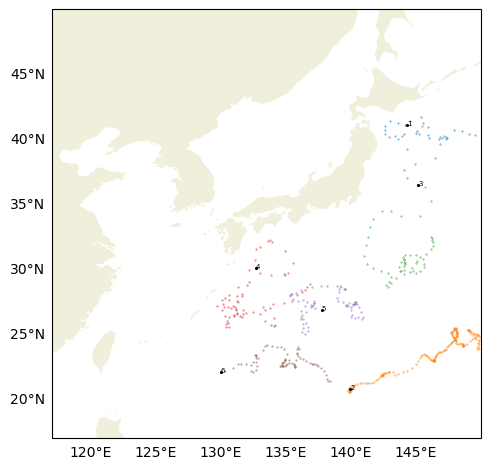

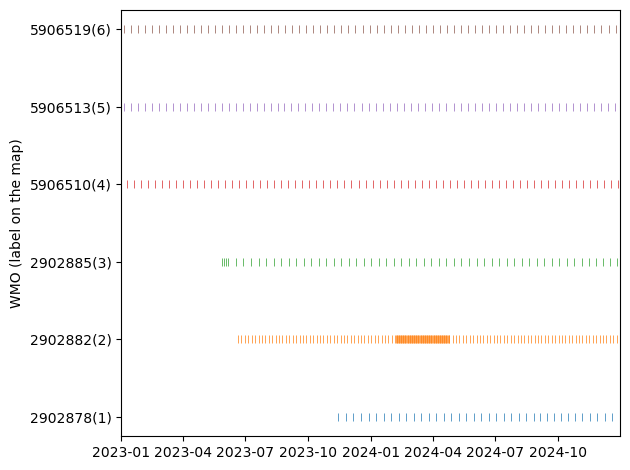

In [52]:
plt.close('all')

# --- 1. Map and Plot Setup ---
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax1.add_feature(cft.LAND)
ax1.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color="None")
gl.top_labels = False
gl.right_labels = False

fig2 = plt.figure()
ax2 = fig2.add_subplot(1,1,1)

# We use a colormap called 'tab10' which gives 10 different colors.
list_cmap = plt.colormaps['tab10'].colors

# Initialize the count for floats passing the three criteria
ind_pass = 0
daimei = []

for wmo, group in df_index_filtered.groupby('wmo'):
    
    # Sort the group by time just to be safe
    group = group.sort_values('datetime')
    
    # Ignore if there is only one profile
    if len(group) == 1:
        continue

    # Check criteria
    valid_freq = group['datetime'].diff().max() < pd.to_timedelta(minfreq, unit='D')
    valid_drift = calculate_float_speed(group['longitude'], group['latitude'], group['datetime']) < maxdrift
    valid_dur = (group['datetime'].max() - group['datetime'].min()) > pd.to_timedelta(mindays, unit='D')

    # If it passes all criteria, plot and save!
    if valid_freq and valid_drift and valid_dur:
        iro = list_cmap[ind_pass % len(list_cmap)]
        
        # Plot Map (ax1)
        ax1.scatter(group['longitude'], group['latitude'], color=iro, 
                    transform=ccrs.PlateCarree(), zorder=3, s=0.1)
        ax1.scatter(group['longitude'].iloc[-1], group['latitude'].iloc[-1], color='k', 
                    marker='.', transform=ccrs.PlateCarree(), zorder=4, s=6)
        ax1.text(group['longitude'].iloc[-1], group['latitude'].iloc[-1], str(ind_pass+1), color='k', 
                 transform=ccrs.PlateCarree(), zorder=5, fontsize=5)
        
        # Plot Time Series (ax2)
        ax2.scatter(group['datetime'], [ind_pass]*len(group), color=iro, marker='|', linewidths=0.5)
        
        # label for time series figure
        daimei.append(f"{wmo}({ind_pass+1})")        
        
        ind_pass += 1

# Save the current time for creating a unique id for the figures.
now = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

fig.tight_layout()
fig.savefig(f'map_search_{now}', dpi=300, bbox_inches='tight')

ax2.set_yticks(range(len(daimei)))
ax2.set_yticklabels(daimei)
ax2.set_xlim(datetime.strptime(str(date0), '%Y-%m-%d'), datetime.strptime(str(date1), '%Y-%m-%d'))
ax2.set_ylabel('WMO (label on the map)')
fig2.tight_layout()
fig2.savefig(f'timeline_search_{now}', dpi=300, bbox_inches='tight')

### Create the function

In [59]:
def map_and_timeline(df_index, lon0, lon1, lat0, lat1, mindays, minfreq, maxdrift, note=None):

    plt.close('all')
    
    # --- 1. Map and Plot Setup ---
    fig = plt.figure()
    ax1 = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    ax1.add_feature(cft.LAND)
    ax1.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())
    gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color="None")
    gl.top_labels = False
    gl.right_labels = False
    
    fig2 = plt.figure()
    ax2 = fig2.add_subplot(1,1,1)
    
    # We use a colormap called 'tab10' which gives 10 different colors.
    list_cmap = plt.colormaps['tab10'].colors
    
    # Initialize the count for floats passing the three criteria
    ind_pass = 0
    daimei = []
    
    for wmo, group in df_index.groupby('wmo'):
        
        # Sort the group by time just to be safe
        group = group.sort_values('datetime')
        
        # Ignore if there is only one profile
        if len(group) == 1:
            continue
    
        # Check criteria
        valid_freq = group['datetime'].diff().max() < pd.to_timedelta(minfreq, unit='D')
        valid_drift = calculate_float_speed(group['longitude'], group['latitude'], group['datetime']) < maxdrift
        valid_dur = (group['datetime'].max() - group['datetime'].min()) > pd.to_timedelta(mindays, unit='D')
    
        # If it passes all criteria, plot and save!
        if valid_freq and valid_drift and valid_dur:
            iro = list_cmap[ind_pass % len(list_cmap)]
            
            # Plot Map (ax1)
            ax1.scatter(group['longitude'], group['latitude'], color=iro, 
                        transform=ccrs.PlateCarree(), zorder=3, s=0.1)
            ax1.scatter(group['longitude'].iloc[-1], group['latitude'].iloc[-1], color='k', 
                        marker='.', transform=ccrs.PlateCarree(), zorder=4, s=6)
            ax1.text(group['longitude'].iloc[-1], group['latitude'].iloc[-1], str(ind_pass+1), color='k', 
                     transform=ccrs.PlateCarree(), zorder=5, fontsize=5)
            
            # Plot Time Series (ax2)
            ax2.scatter(group['datetime'], [ind_pass]*len(group), color=iro, marker='|', linewidths=0.5)
            
            # label for time series figure
            daimei.append(f"{wmo}({ind_pass+1})")        
            
            ind_pass += 1
    
    # Save the current time for creating a unique id for the figures.
    now = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
    fig.tight_layout()
    
    ax2.set_yticks(range(len(daimei)))
    ax2.set_yticklabels(daimei)
    ax2.set_xlim(datetime.strptime(str(date0), '%Y-%m-%d'), datetime.strptime(str(date1), '%Y-%m-%d'))
    ax2.set_ylabel('WMO (label on the map)')
    fig2.tight_layout()

    # Save the figures
    if note:
        fig.savefig(f'map_search_{note}_{now}', dpi=300, bbox_inches='tight')
        fig2.savefig(f'timeline_search_{note}_{now}', dpi=300, bbox_inches='tight')
    else:
        fig.savefig(f'map_search_{now}', dpi=300, bbox_inches='tight')
        fig2.savefig(f'timeline_search_{now}', dpi=300, bbox_inches='tight')

---

## 📝 Exercises

Now that we have learned how to use the index file to search for floats and generate figures, let's do a few exercises by writing some codes. Keep in mind that we can use the three functions we have developed (`load_index`, `filter_index`, and `map_and_timeline`) for convenience. If you forgot which inputs are needed for functions, press `Shift + Tab` after the opening parenthesis (e.g., type `filter_index(` and then press `Shift + Tab`).

### Exercise 1: Draw a global map of BGC-Argo floats that had provided chlorophyll-a measurements in the past 24 hours.

/var/folders/cy/s63ny9414x32ypnwsfk_cfm40000gn/T/ipykernel_867/3603923461.py:31: RuntimeWarning: divide by zero encountered in scalar divide
  speed = np.sum(distances) / np.sum(time_deltas) / 86400.
/var/folders/cy/s63ny9414x32ypnwsfk_cfm40000gn/T/ipykernel_867/786946938.py:65: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(datetime.strptime(str(date0), '%Y-%m-%d'), datetime.strptime(str(date1), '%Y-%m-%d'))


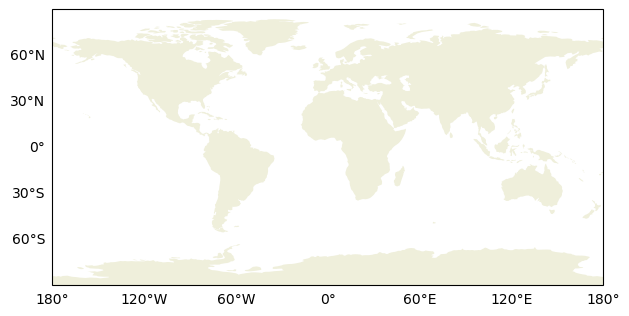

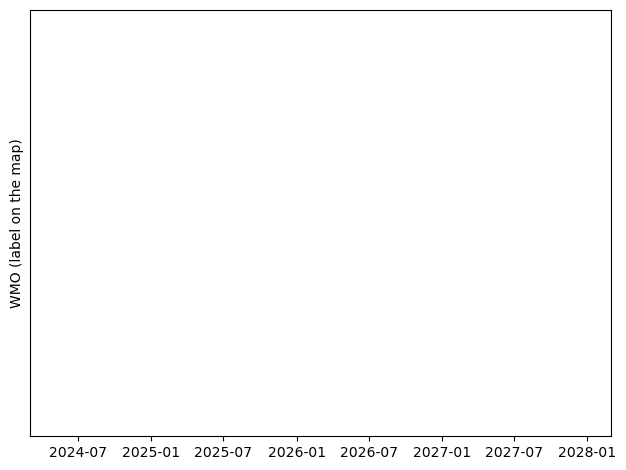

In [61]:
map_and_timeline(df_filter, lon0, lon1, lat0, lat1, mindays, minfreq, maxdrift, note)

KeyError: 'wmo'

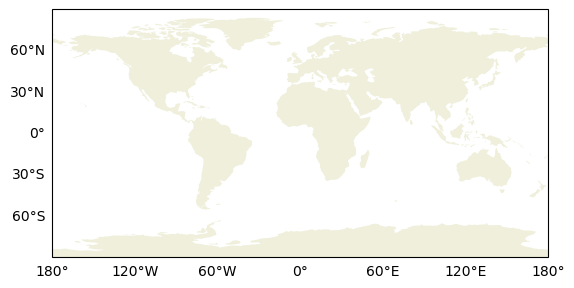

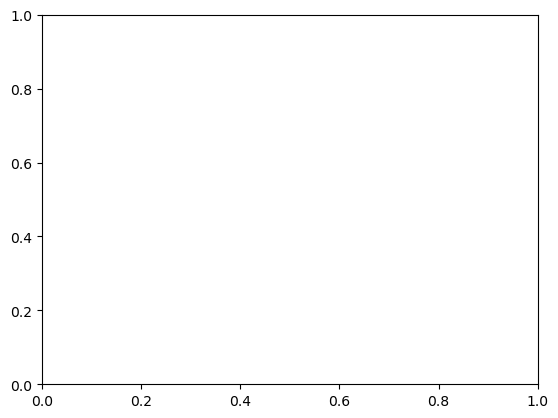

In [60]:
lon0 = -180
lon1 = 180
lat0 = -90
lat1 = 90
date0 = '2026-03-01'
date1 = '2026-03-01'
bgc_parameters = 'CHLA'
mindays = 1
maxdrift = 100
note = 'exercise1'
df_index = load_index()
df_filter = filter_index(df_index, lon0, lon1, lat0, lat1, date0, date1, bgc_parameters)
map_and_timeline(df_filter, lon0, lon1, lat0, lat1, mindays, minfreq, maxdrift, note)

### Exercise 2: Draw a regional map of *full-sensor* BGC-Argo floats in the Pacific Ocean since 2018.

In [ ]:
df_filter = filter_index(120, -45, 

### Exercise 3: Draw a regional map of slowly-drifting BGC-Argo floats equipped with nitrate

Signature:
filter_index(
    df_index_in,
    lon0_in,
    lon1_in,
    lat0_in,
    lat1_in,
    date0_in,
    date1_in,
    bgc_parameters_in,
)
Docstring: <no docstring>
File:      /var/folders/cy/s63ny9414x32ypnwsfk_cfm40000gn/T/ipykernel_92209/3474893235.py
Type:      function